Style Transfer Based on Gatys et al. (2016)

[Paper Link](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf)

Modifications:
- initializing the image with the content image instead of white noise
- not normalizing the VGG model such that the mean activation is 1
- using max pooling rather than average pooling
- using an Adam optimizer instead of L-BFGS
- changing the per-layer style loss

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
import matplotlib.pyplot as plt
import time
import os
from tqdm import tqdm

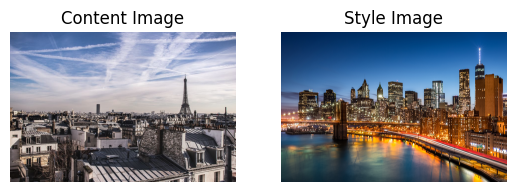

In [3]:
# Global constants
CONTENT_WEIGHT = 1e4
STYLE_WEIGHT = 1
MAX_DIM = 512  # Reduced image size to avoid memory issues
ITERATIONS = 1000

# Define content and style layers according to the paper
CONTENT_LAYER = 'block4_conv2'
STYLE_LAYERS = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

path_to_proj = "/content/drive/MyDrive/Master's/Second Year Grad/CV/CV Final Project"
content_img = "images/paris.jpg"
style_img = "photorealistic/nyc.jpg"

save_dir = os.path.join(path_to_proj, 'code/Final_Implementations/results')

content_path = os.path.join(path_to_proj, 'code/dataset', content_img)
style_path = os.path.join(path_to_proj, 'code/dataset', style_img)

# making save_dir if needed
os.makedirs(save_dir, exist_ok=True)

# showing initial images
fig, axs = plt.subplots(1, 2)

axs[0].set_title('Content Image')
axs[1].set_title('Style Image')

axs[0].axis('off')
axs[1].axis('off')
axs[0].imshow(plt.imread(content_path))
axs[1].imshow(plt.imread(style_path))
plt.show()

Load in images

In [4]:
def load_and_process_image(path, max_dim=MAX_DIM):
    """Load and preprocess an image for VGG19 with smaller dimensions."""
    img = load_img(path)

    # Resize image while preserving aspect ratio
    long_dim = max(img.size)
    scale = max_dim / long_dim
    new_size = tuple([int(dim * scale) for dim in img.size])
    img = img.resize(new_size)

    # Convert to array and add batch dimension
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for VGG19
    img_array = preprocess_input(img_array)

    return img_array

In [5]:
def deprocess_image(processed_img):
    """Convert processed image back to displayable format."""
    x = processed_img.copy()

    # Remove batch dimension
    if len(x.shape) == 4:
        x = np.squeeze(x, axis=0)

    # Undo VGG preprocessing
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]  # Convert BGR to RGB

    # Clip to valid range
    x = np.clip(x, 0, 255).astype('uint8')

    return x

In [6]:
content_image = load_and_process_image(content_path)
style_image = load_and_process_image(style_path)

Defining loss and helper functions

In [7]:
def gram_matrix(input_tensor):
    """Memory-efficient implementation of Gram matrix calculation."""
    # Ensure we're working with float32
    input_tensor = tf.cast(input_tensor, tf.float32)

    # Get dimensions
    shape = tf.shape(input_tensor)
    batch_size, height, width, num_filters = shape[0], shape[1], shape[2], shape[3]

    # Reshape the tensor: [batch_size, (height * width), num_filters]
    features = tf.reshape(input_tensor, (batch_size, height * width, num_filters))

    # Calculate gram matrix with batched matmul for better memory efficiency
    # G = F * F^T
    gram = tf.matmul(features, features, transpose_a=True)

    # Normalize by dividing by the number of locations (height * width)
    gram = gram / tf.cast(height * width, tf.float32)

    return gram

In [8]:
@tf.function
def compute_content_loss(content_features, target_features):
    """Compute content loss as per the paper."""
    return (1/2) * tf.reduce_sum(tf.square(content_features - target_features))

In [9]:
@tf.function
def compute_style_layer_loss(style_features, target_features):
    """Compute style loss as per the paper."""
    target_gram = gram_matrix(target_features)
    style_gram = gram_matrix(style_features)

    return tf.reduce_sum(tf.square(style_gram - target_gram))

In [10]:
@tf.function
def compute_loss(model, image, content_features, style_features):
    """Compute the total loss."""
    with tf.GradientTape() as tape:
        tape.watch(image)

        # Get features of current image
        x_features = model(image)

        # Content loss
        content_loss = compute_content_loss(content_features[CONTENT_LAYER], x_features[CONTENT_LAYER])

        # Style loss
        style_loss = tf.add_n([
            compute_style_layer_loss(style_features[name], x_features[name])
            for name in STYLE_LAYERS
        ])
        style_loss *= float(1/len(STYLE_LAYERS))

        # Total loss
        total_loss = (CONTENT_WEIGHT * content_loss) + (STYLE_WEIGHT * style_loss)

    # Get gradients
    grads = tape.gradient(total_loss, image)

    return total_loss, grads

In [11]:
def get_feature_representations(model, content_image, style_image):
    """Extract content and style features."""

    # Get feature representations
    content_outputs = model(content_image)
    style_outputs = model(style_image)

    # Extract content and style features
    content_features = {CONTENT_LAYER: content_outputs[CONTENT_LAYER]}

    # Pre-compute gram matrices for style layers to save memory
    style_features = {layer_name: value
                     for layer_name, value in style_outputs.items()
                     if layer_name in STYLE_LAYERS}

    return content_features, style_features

Loading in Model:

In [12]:
def get_model():
    vgg = VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    outputs = {}
    for name in [CONTENT_LAYER] + STYLE_LAYERS:
        outputs[name] = vgg.get_layer(name).output
    model = tf.keras.Model(vgg.input, outputs)

    return model

Performing Style Transfer

In [13]:
def run_style_transfer(content_path, style_path):
    """Run the style transfer algorithm."""
    print("Building model...")
    model = get_model()

    print("\nLoading images and extracting features...")
    content_features, style_features = get_feature_representations(
        model, content_image, style_image
    )

    # Initialize as content image
    generated_image = tf.Variable(content_image, dtype=tf.float32)

    # Create optimizer
    optimizer = tf.optimizers.Adam(learning_rate=5.0)

    # Optimize with Adam
    print(f"\nStarting optimization with Adam for {ITERATIONS} iterations...")
    start_time = time.time()

    best_loss = float('inf')
    best_img = None

    # Main optimization loop
    for i in range(ITERATIONS):
        print(f"Iteration {i+1}/{ITERATIONS}")
        iteration_start = time.time()

        # Optimization loop
        loss, grad = compute_loss(model, generated_image,
                                  content_features, style_features)

        # Apply gradients
        optimizer.apply_gradients([(grad, generated_image)])

        if loss < best_loss:
            best_loss = loss
            best_img = generated_image.numpy()

        print(f"Loss: {loss}")
        print(f"Time for iteration {i+1}: {time.time() - iteration_start:.2f}s")

    # Return the best result
    final_img = best_img if best_img is not None else generated_image
    final_img = deprocess_image(final_img)

    print(f"Total time: {time.time() - start_time:.2f}s")

    return final_img

In [14]:
gen_img = run_style_transfer(content_path, style_path)

Building model...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Loading images and extracting features...

Starting optimization with Adam for 1000 iterations...
Iteration 1/1000
Loss: 3809987373563904.0
Time for iteration 1: 3.24s
Iteration 2/1000
Loss: 2869536906805248.0
Time for iteration 2: 0.05s
Iteration 3/1000
Loss: 2445524582006784.0
Time for iteration 3: 0.06s
Iteration 4/1000
Loss: 2309868845268992.0
Time for iteration 4: 0.06s
Iteration 5/1000
Loss: 2119916400410624.0
Time for iteration 5: 0.06s
Iteration 6/1000
Loss: 1959489976664064.0
Time for iteration 6: 0.06s
Iteration 7/1000
Loss: 1827166060806144.0
Time for iteration 7: 0.06s
Iteration 8/1000
Loss: 1728793592987648.0
Time for iteration 8: 0.06s
Iteration 9/1000
Loss: 1652159028396032.0
Time for iteration 9: 0.06s
Iteration 10/1000
Loss: 1589393718509568.0
Time for iteration 10: 0.06s
Iteration 11/1000
Loss: 1537235233013760.0
Time for iteration 11: 0.06s
Iteration 12/1000
Loss: 1491011184361472.0
Time for iterat

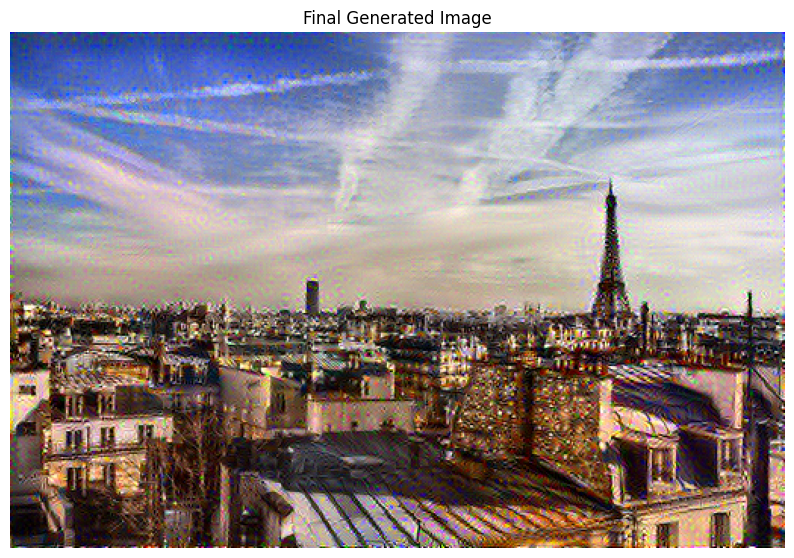

In [15]:
# Display result
plt.figure(figsize=(10, 10))
plt.title(f'Final Generated Image')
plt.imshow(gen_img)
plt.axis('off')
plt.show()

In [ ]:
# Save result
content_name = content_img.split('/')[1].replace('.jpg', '')
style_name = style_img.split('/')[1].replace('.jpg', '')

save_path = os.path.join(save_dir, f"{content_name}_{style_name}_opt.jpg")
array_to_img(gen_img).save(save_path)
print(f"Style transfer complete! Image saved as '{content_name}_{style_name}_opt.jpg'")

Style transfer complete! Image saved as 'paris_nyc_opt.jpg'
